## **Notebook 01: EDA - Análise Exploratória Dataset (dados_ipdm.csv):**

### **Fase 1 EDA (Exploratory Data Analysis) + Limpeza e Estruturação dos Dados**

**IMPORTANTE 1:** Pacote "Pacman" adicionado, ele deixará a instalação de libs. muito mais limpa!!!

In [176]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(glue)

In [177]:
url <- "C:/Users/Ivan/Documents/Pasta-Documentos-PC-antigo/GITHUB-Meus-Repositorios/PesquisaTeoAprendiEstati_2026/data/processed/Datasets_IPDM/doze_medidas_desv/"

get_dataframe <- function(url, nm_arquivo) {
  df_x <- read.csv(file = paste0(url, nm_arquivo))
  return (df_x)
}

In [178]:
df1 <- get_dataframe(url, '1_medida_longevi_1.csv')
df2 <- get_dataframe(url, '2_medida_longevi_2.csv')
df3 <- get_dataframe(url, '3_medida_longevi_3.csv')
df4 <- get_dataframe(url, '4_medida_longevi_4.csv')
df5 <- get_dataframe(url, '5_medida_escolari_1.csv')
df6 <- get_dataframe(url, '6_medida_escolari_2.csv')
df7 <- get_dataframe(url, '7_medida_escolari_3.csv')
df8 <- get_dataframe(url, '8_medida_escolari_4.csv')
df9 <- get_dataframe(url, '9_medida_economia_1.csv')
df10 <- get_dataframe(url, '10_medida_economia_2.csv')
df11 <- get_dataframe(url, '11_medida_consumo_1.csv')
df12 <- get_dataframe(url, '12_medida_consumo_2.csv')

In [179]:
print(dim(df1))

[1] 54  7


In [180]:
head(df1,1)

,cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,3506359,Bertioga,13.89879,2014,Longevidade,11.45,Taxas de mortalidade infantil (por mil nascidos vivos)


In [181]:
summary(df1$valor)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  7.806  12.118  13.534  13.715  15.311  20.146 

In [182]:
str(df1)

'data.frame':	54 obs. of  7 variables:
 $ cod_ibge    : int  3506359 3506359 3506359 3506359 3506359 3506359 3513504 3513504 3513504 3513504 ...
 $ municipio   : chr  "Bertioga" "Bertioga" "Bertioga" "Bertioga" ...
 $ valor       : num  13.9 12.4 13.8 13.1 14.4 ...
 $ ano         : int  2014 2016 2018 2020 2022 2024 2014 2016 2018 2020 ...
 $ tipo        : chr  "Longevidade" "Longevidade" "Longevidade" "Longevidade" ...
 $ valor_estado: num  11.4 10.8 10.8 10.5 10.3 ...
 $ metrica     : chr  "Taxas de mortalidade infantil (por mil nascidos vivos)" "Taxas de mortalidade infantil (por mil nascidos vivos)" "Taxas de mortalidade infantil (por mil nascidos vivos)" "Taxas de mortalidade infantil (por mil nascidos vivos)" ...


In [183]:
summary(df1)

    cod_ibge           municipio      valor             ano      
 Min.   :3506359   Length   :54   Min.   : 7.806   Min.   :2014  
 1st Qu.:3518701   N.unique : 9   1st Qu.:12.118   1st Qu.:2016  
 Median :3531100   N.blank  : 0   Median :13.534   Median :2019  
 Mean   :3529987   Min.nchar: 6   Mean   :13.715   Mean   :2019  
 3rd Qu.:3541000   Max.nchar:12   3rd Qu.:15.311   3rd Qu.:2022  
 Max.   :3551009                  Max.   :20.146   Max.   :2024  
        tipo     valor_estado        metrica  
 Length   :54   Min.   :10.33   Length   :54  
 N.unique : 1   1st Qu.:10.47   N.unique : 1  
 N.blank  : 0   Median :10.77   N.blank  : 0  
 Min.nchar:11   Mean   :10.82   Min.nchar:54  
 Max.nchar:11   3rd Qu.:11.16   Max.nchar:54  
                Max.   :11.45                 

In [194]:
library(glue) # Lib p/ concatenar string c/ variável amigo.

ShapiroTest <- function(df_column) {
    dados_limpos <- na.omit(df_column)
    result_shapiro <- shapiro.test(dados_limpos)

    options(repr.plot.width = 10, repr.plot.height = 5)
    par(mfrow = c(1,2))

    # Gráfico 1: Histograma com linha de densidade
    hist(dados_limpos, probability = TRUE, main = "Histograma", xlab = "Valores")
    lines(density(dados_limpos), col = "red", lwd = 2)

    # Gráfico 2: Q-Q Plot (Gráfico de Quantil-Quantil)
    qqnorm(dados_limpos, main = "Q-Q Plot")
    qqline(dados_limpos, col = "red", lwd = 2)

    p_valor <- result_shapiro$p.value
    if (p_valor > 0.05) {
        cat("Resultados do teste:\n")
        cat("p-value =", p_valor, "\n")
        cat("=> Os dados seguem uma distribuição NORMAL (p > 0.05).\n")
        cat("Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).\n") 
    } else {
        cat("Resultados do teste:\n")
        cat("p-value =", p_valor, "\n")
        cat("=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).\n")
        cat("Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.\n")
    }
}

check_normality_using_Shapiro <- function(df_column) {
    fazer_shappiro = FALSE
    n_registros <- sum(!is.na(df_column))
    if (n_registros >= 20 && n_registros <= 100) 
        fazer_shappiro = TRUE
    if (fazer_shappiro == TRUE) 
        ShapiroTest(df_column)
}

Resultados do teste:
p-value = 0.8527675 
=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


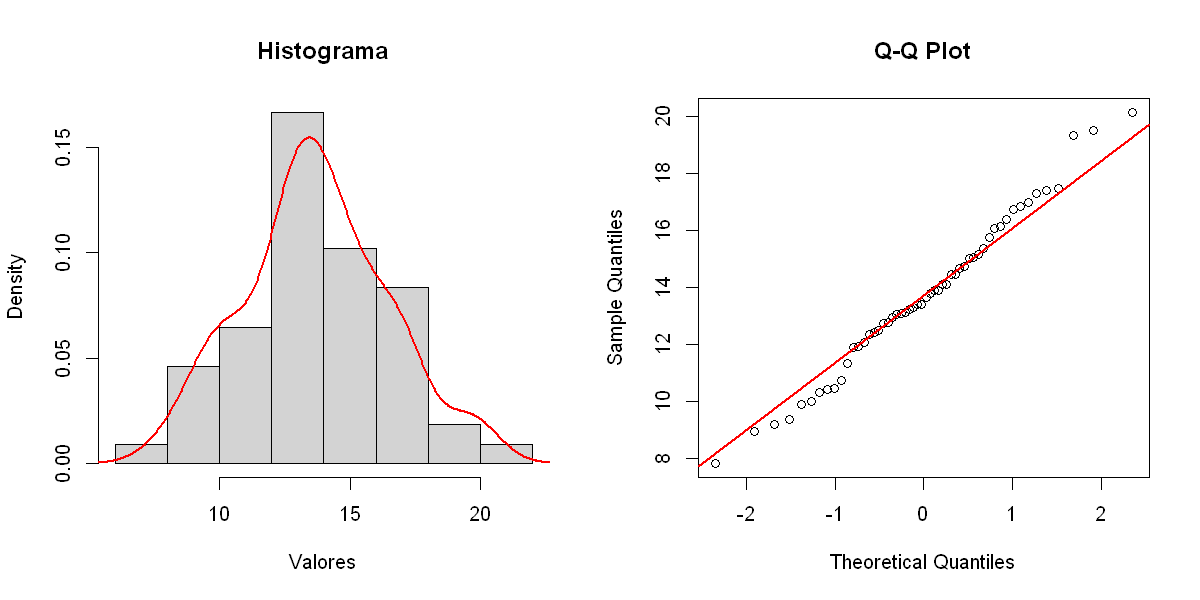

In [195]:
check_normality_using_Shapiro(df1$valor)

Resultados do teste:
p-value = 0.7708141 
=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


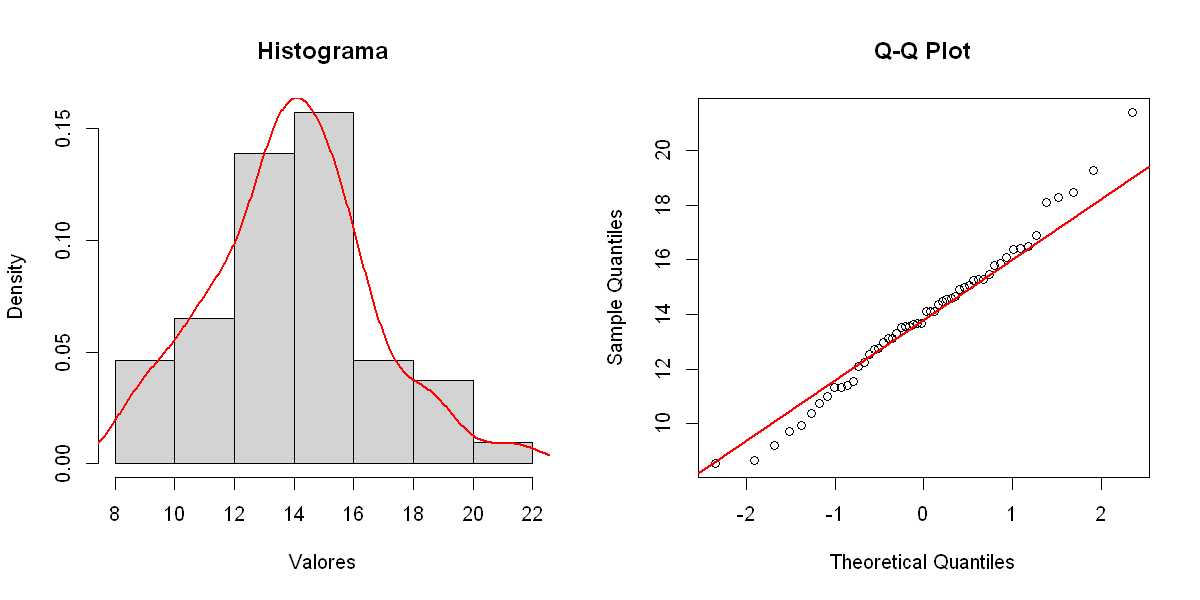

In [196]:
check_normality_using_Shapiro(df2$valor)

Resultados do teste:
p-value = 0.658588 
=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


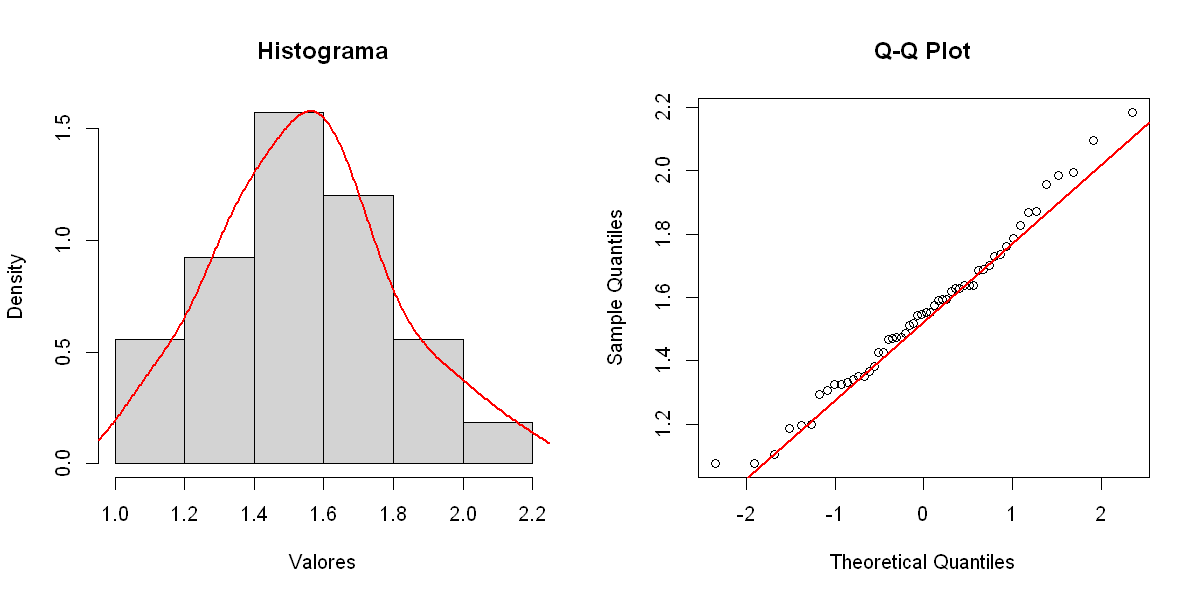

In [197]:
check_normality_using_Shapiro(df3$valor)

Resultados do teste:
p-value = 0.01319688 
=> Os dados NÃO seguem uma distribuição normal (p <= 0.05).
Recomendação: Considere usar testes não paramétricos (ex: Wilcoxon, Kruskal-Wallis) ou transformar os dados.


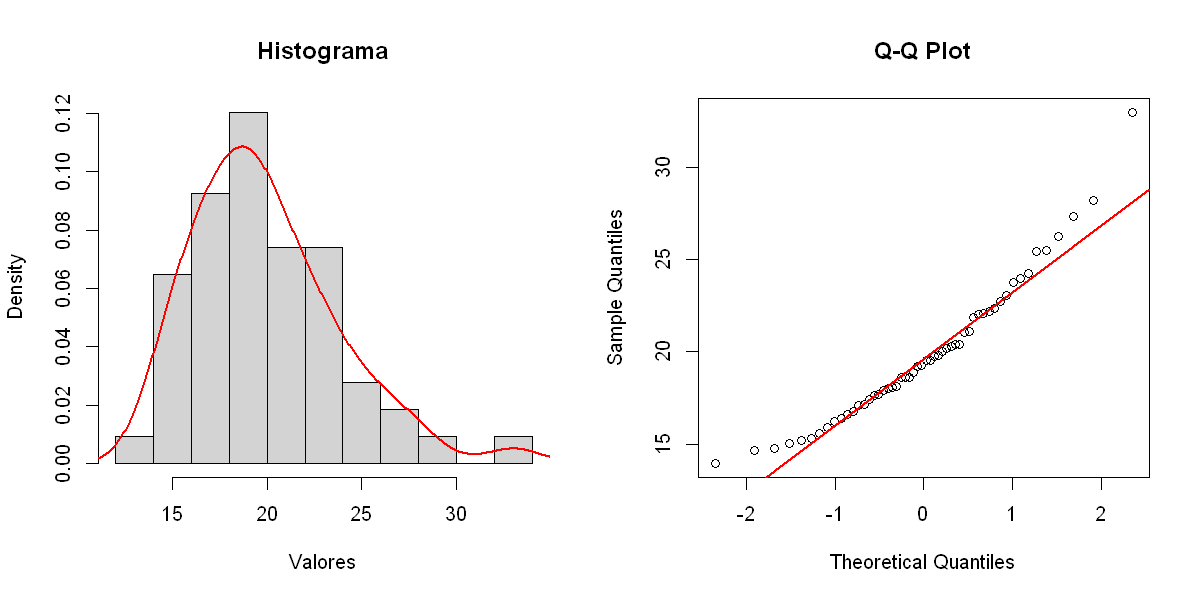

In [198]:
check_normality_using_Shapiro(df4$valor)

Resultados do teste:
p-value = 0.09854821 
=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


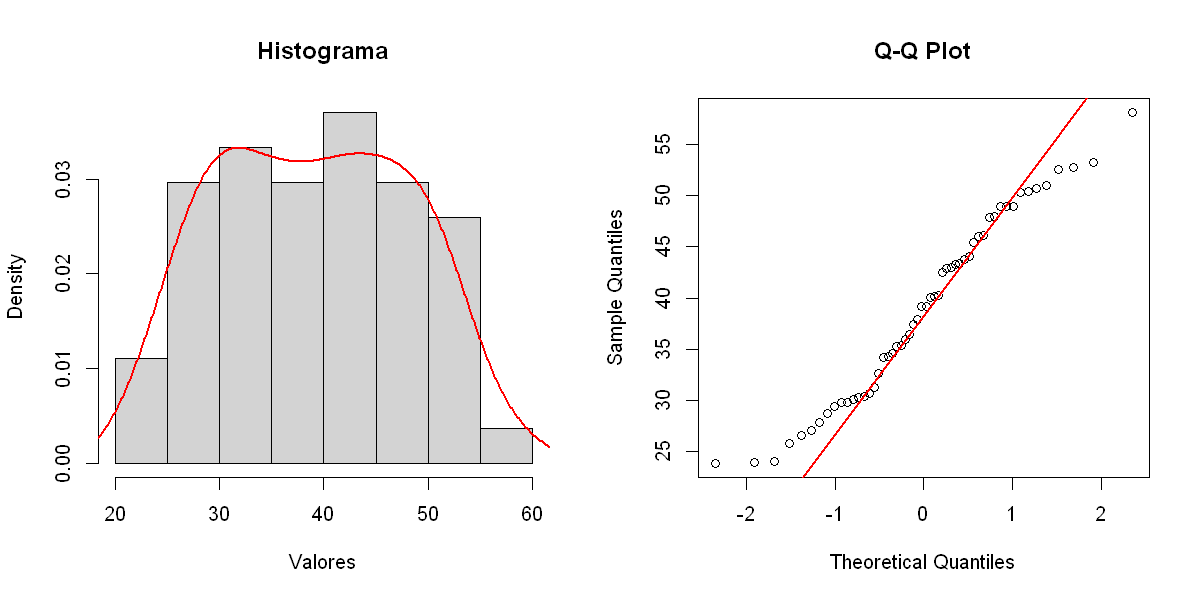

In [199]:
check_normality_using_Shapiro(df5$valor)

Resultados do teste:
p-value = 0.6911499 
=> Os dados seguem uma distribuição NORMAL (p > 0.05).
Recomendação: Pode utilizar testes paramétricos (ex: Teste t, ANOVA).


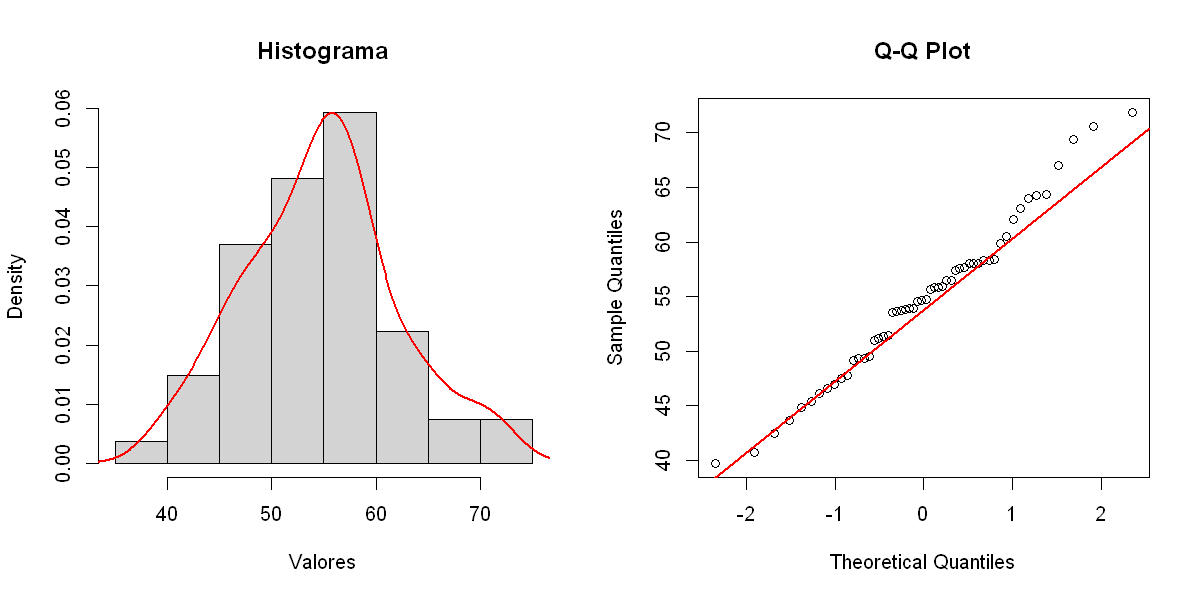

In [200]:
check_normality_using_Shapiro(df6$valor)